# 4 - Sensor Coverage

This notebook summarizes sensor availability and data coverage across waves.

## Import libraries and define paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.transforms import blended_transform_factory

%matplotlib inline

np.random.seed(42)

from utils import (
    WAVE_LABELS, WAVE_KEYS,
    get_data_root, set_paper_style,
)

DATA_ROOT = get_data_root()
set_paper_style()


## Load data

In [2]:
from utils import load_esm_28d


## Data processing

In [3]:
_, _, esm_all_28d, esm_by_wave_28d, esm_28d_stats = load_esm_28d(
    wave_keys=WAVE_KEYS,
    data_root=DATA_ROOT,
    include_userinfo=False,
    include_study_day=False,
)


---
## Visuals 

### Sensor Availability per Wave
Insight: Highlights which sensing streams are available in each wave.

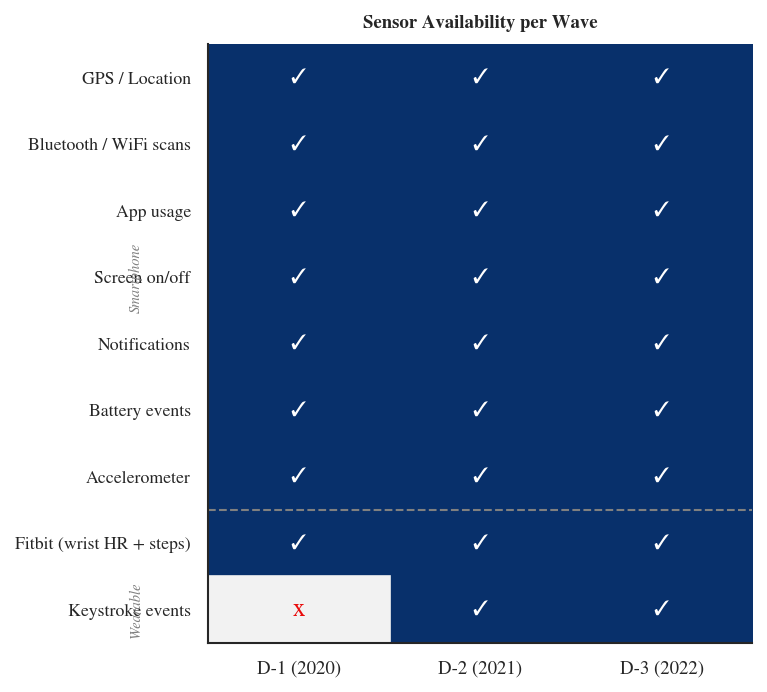

In [14]:
# Sensor names (rows) — ordered from smartphone sensors to wearables
SENSORS = [
    "GPS / Location",
    "Bluetooth / WiFi scans",
    "App usage",
    "Screen on/off",
    "Notifications",
    "Battery events",
    "Accelerometer",
    "Fitbit (wrist HR + steps)",
    # "Polar H10 (chest ECG/HRV)",
    "Keystroke events",
]

# Availability matrix: rows = sensors, cols = [D-1, D-2, D-3]
# Source: paper specifications (1.0 = available, 0.0 = not available)
AVAILABILITY = np.array([
    [1.0, 1.0, 1.0],   # GPS / Location
    [1.0, 1.0, 1.0],   # Bluetooth / WiFi
    [1.0, 1.0, 1.0],   # App usage
    [1.0, 1.0, 1.0],   # Screen on/off
    [1.0, 1.0, 1.0],   # Notifications
    [1.0, 1.0, 1.0],   # Battery events
    [1.0, 1.0, 1.0],   # Accelerometer
    [1.0, 1.0, 1.0],   # Fitbit
    # [1.0, 1.0, 0.0],   # Polar H10 — removed in D-3
    [0.0, 1.0, 1.0],   # Keystroke — added in D-2
])

fig, ax = plt.subplots(figsize=(5.0, 4.5), constrained_layout=True)
ax.imshow(AVAILABILITY, cmap="Blues", vmin=0, vmax=1, aspect="auto")

# Overlay availability annotations (+ = present, x = absent)
for i in range(AVAILABILITY.shape[0]):
    for j in range(AVAILABILITY.shape[1]):
        if AVAILABILITY[i, j] == 0.0:
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   color="#f2f2f2", zorder=2))
            ax.text(j, i, "x", ha="center", va="center",
                    fontsize=12, color="#E90B0B", zorder=3)
        else:
            ax.text(j, i, r"$\checkmark$", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold",
                    zorder=3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(WAVE_LABELS, fontsize=9)
ax.set_yticks(range(len(SENSORS)))
ax.set_yticklabels(SENSORS, fontsize=8.5)

# Divider between smartphone and wearable groups
ax.axhline(6.5, color="gray", lw=1, ls="--")

# Side category labels
ax.text(-0.9, 3.0, "Smartphone", ha="center", va="center",
        fontsize=7, color="gray", rotation=90, style="italic")
ax.text(-0.9, 8.0, "Wearable", ha="center", va="center",
        fontsize=7, color="gray", rotation=90, style="italic")

ax.set_title("Sensor Availability per Wave", fontweight="bold", fontsize=9, pad=8)
plt.show()

### Sensor Availability per Wave (Raw-verified, Full)
Insight: Full inventory of raw sensor modalities per wave, verified by scanning the raw file system across all participants in `/var/nfs_share/harvard_dataverse/{D#1,D#2,D#3}/Sensor/`. Replaces the curated paper view with every modality that ships in the raw release. The "Accelerometer" row from the curated view is renamed to "Activity recognition" because the raw data contains only Google Activity Recognition API events (`ActivityEvent.csv`), not raw tri-axial accelerometer.

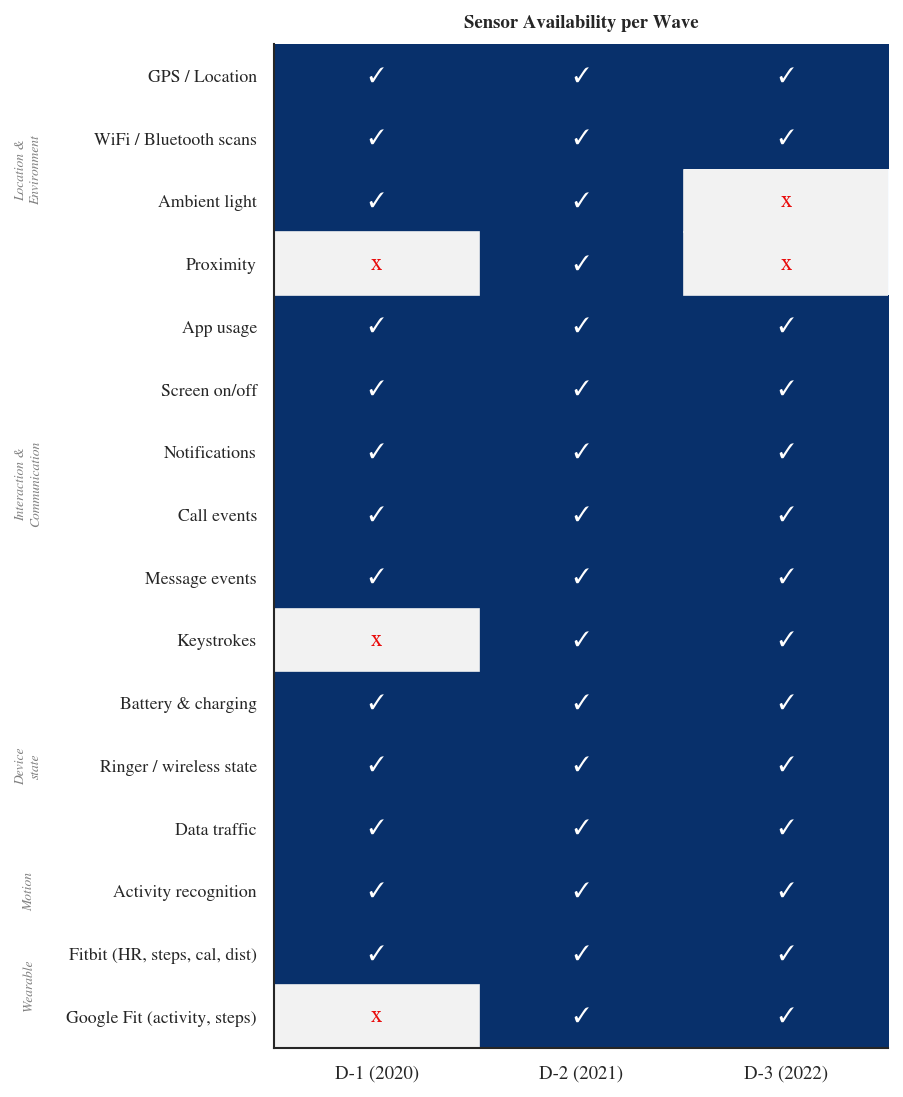

In [ ]:
# Full raw-verified sensor availability — grouped by functional modality.
# Availability is 1.0 if the corresponding raw CSV is present for every
# participant in that wave, 0.0 if it is absent for every participant.

SENSORS_FULL = [
    # Location & Environment
    "GPS / Location",
    "WiFi / Bluetooth scans",
    "Ambient light",
    "Proximity",
    # Interaction & Communication
    "App usage",
    "Screen on/off",
    "Notifications",
    "Call events",
    "Message events",
    "Keystrokes",
    # Device state
    "Battery & charging",
    "Ringer / wireless state",
    "Data traffic",
    # Motion (derived)
    "Activity recognition",
    # Wearable
    "Fitbit (HR, steps, cal, dist)",
    "Google Fit (activity, steps)",
]

# rows = sensors, cols = [D-1, D-2, D-3]
AVAILABILITY_FULL = np.array([
    # Location & Environment
    [1.0, 1.0, 1.0],   # GPS / Location                (Location.csv)
    [1.0, 1.0, 1.0],   # WiFi / Bluetooth scans        (WifiScan.csv, BluetoothScan.csv)
    [1.0, 1.0, 0.0],   # Ambient light                 (Light.csv) — dropped in D-3
    [0.0, 1.0, 0.0],   # Proximity                     (Proximity.csv) — D-2 only
    # Interaction & Communication
    [1.0, 1.0, 1.0],   # App usage                     (AppUsageEvent.csv, InstalledApp.csv)
    [1.0, 1.0, 1.0],   # Screen on/off                 (ScreenEvent.csv, OnOffEvent.csv)
    [1.0, 1.0, 1.0],   # Notifications                 (NotificationEvent.csv)
    [1.0, 1.0, 1.0],   # Call events                   (CallEvent.csv)
    [1.0, 1.0, 1.0],   # Message events                (MessageEvent.csv)
    [0.0, 1.0, 1.0],   # Keystrokes                    (KeyEvent.csv) — added in D-2
    # Device state
    [1.0, 1.0, 1.0],   # Battery & charging            (BatteryEvent, ChargeEvent, PowerSaveEvent, DozeModeEvent)
    [1.0, 1.0, 1.0],   # Ringer / wireless state       (RingerModeEvent, WirelessStateEvent)
    [1.0, 1.0, 1.0],   # Data traffic                  (DataTraffic.csv)
    # Motion (derived)
    [1.0, 1.0, 1.0],   # Activity recognition          (ActivityEvent.csv, ActivityTransition.csv)
    # Wearable
    [1.0, 1.0, 1.0],   # Fitbit                        (Fitbit-HeartRate / StepCount / Calorie / Distance)
    [0.0, 1.0, 1.0],   # Google Fit                    (Fitness-Activity / Calorie / Distance / StepCount) — added in D-2
])

# Group boundary rows (drawn between row i and i+1)
GROUP_DIVIDERS = [3.5, 9.5, 12.5, 13.5]
SMARTPHONE_END = 13.5  # main divider between smartphone and wearable

fig, ax = plt.subplots(figsize=(5.8, 7.2), constrained_layout=True)
ax.imshow(AVAILABILITY_FULL, cmap="Blues", vmin=0, vmax=1, aspect="auto")

for i in range(AVAILABILITY_FULL.shape[0]):
    for j in range(AVAILABILITY_FULL.shape[1]):
        if AVAILABILITY_FULL[i, j] == 0.0:
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   color="#f2f2f2", zorder=2))
            ax.text(j, i, "x", ha="center", va="center",
                    fontsize=11, color="#E90B0B", zorder=3)
        else:
            ax.text(j, i, r"$\checkmark$", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold",
                    zorder=3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(WAVE_LABELS, fontsize=9)
ax.set_yticks(range(len(SENSORS_FULL)))
ax.set_yticklabels(SENSORS_FULL, fontsize=8.5)

_tx = blended_transform_factory(ax.transAxes, ax.transData)
_LX = -0.4  # axes fraction; more negative = further left of heatmap
_group_labels = [
    (1.5,  "Location &\nEnvironment"),
    (6.5,  "Interaction &\nCommunication"),
    (11.0, "Device\nstate"),
    (13.0, "Motion"),
    (14.5, "Wearable"),
]
for _y, _txt in _group_labels:
    ax.text(_LX, _y, _txt, transform=_tx,
            ha="center", va="center", fontsize=6.5, color="gray",
            rotation=90, style="italic")

ax.set_title("Sensor Availability per Wave",
             fontweight="bold", fontsize=9, pad=8)
plt.show()

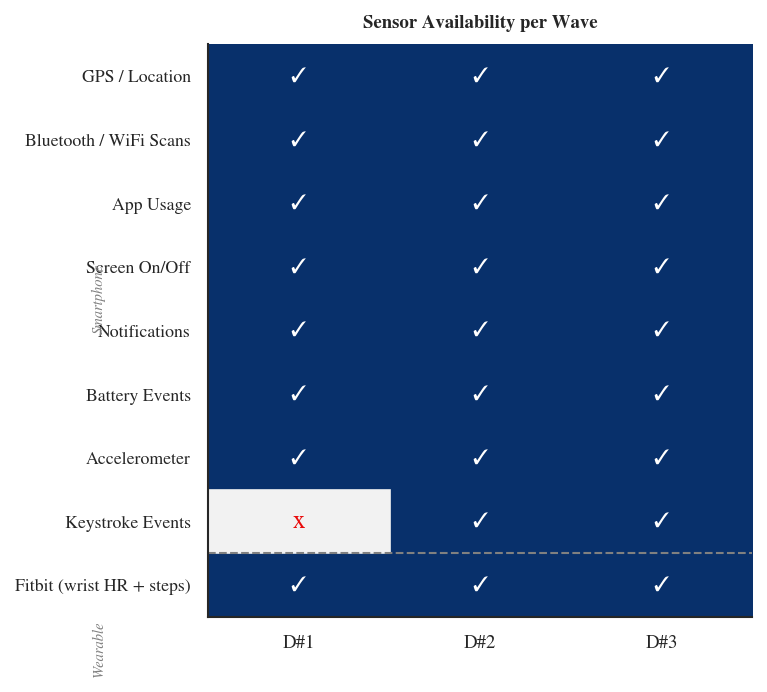

In [6]:
SENSORS = [
    "GPS / Location",
    "Bluetooth / WiFi Scans",
    "App Usage",
    "Screen On/Off",
    "Notifications",
    "Battery Events",
    "Accelerometer",
    "Keystroke Events",
    "Fitbit (wrist HR + steps)",
    # "Polar H10 (chest ECG/HRV)",
]

AVAILABILITY = np.array([
    [1.0, 1.0, 1.0],   # GPS / Location
    [1.0, 1.0, 1.0],   # Bluetooth / WiFi Scans
    [1.0, 1.0, 1.0],   # App Usage
    [1.0, 1.0, 1.0],   # Screen On/Off
    [1.0, 1.0, 1.0],   # Notifications
    [1.0, 1.0, 1.0],   # Battery Events
    [1.0, 1.0, 1.0],   # Accelerometer
    [0.0, 1.0, 1.0],   # Keystroke Events — added in D#2
    [1.0, 1.0, 1.0],   # Fitbit
    # [1.0, 1.0, 0.0],   # Polar H10 — removed in D#3
])

fig, ax = plt.subplots(figsize=(5.0, 4.5), constrained_layout=True)
ax.imshow(AVAILABILITY, cmap="Blues", vmin=0, vmax=1, aspect="auto")

for i in range(AVAILABILITY.shape[0]):
    for j in range(AVAILABILITY.shape[1]):
        if AVAILABILITY[i, j] == 0.0:
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   color="#f2f2f2", zorder=2))
            ax.text(j, i, "x", ha="center", va="center",
                    fontsize=12, color="#E90B0B", zorder=3)
        else:
            ax.text(j, i, r"$\checkmark$", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold",
                    zorder=3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["D#1", "D#2", "D#3"], fontsize=9)
ax.set_yticks(range(len(SENSORS)))
ax.set_yticklabels(SENSORS, fontsize=8.5)

# Divider between smartphone and wearable groups
ax.axhline(7.5, color="gray", lw=1, ls="--")

# Side category labels
ax.text(-1.1, 3.5, "Smartphone", ha="center", va="center",
        fontsize=7, color="gray", rotation=90, style="italic")
ax.text(-1.1, 9.0, "Wearable", ha="center", va="center",
        fontsize=7, color="gray", rotation=90, style="italic")

ax.set_title("Sensor Availability per Wave", fontweight="bold", fontsize=9, pad=8)
plt.show()